## Manipulation of hysteresis loops

This tutorial will provide a few examples for automated data correction/manipulation of (magnetic) hysteresis loops possible with evaluix. These are
1. invert the field and/or magnetization axis
2. Automatic detection and deletion of outliers
3. Smoothing the hysteresis curve with different filters
4. Remove hysteresis opening in saturation
5. Remove common slopes in saturation, i.e. dia- or paramagnetic-like trends
6. Center and eventually normalize the hysteresis loop 

It is recommended to apply the manipulations in the order above, leaving out unnessecary steps. The manipulations ``del_outliers()``, ``rmv_opening()`` and ``slope_correction()`` compare the possibly removed effects with the noise level of the hysteresis loop and are only applied above certain thresholds, which enables their potential usage in automated processes. Nevertheless, all data manipulation steps should be performed with caution.

This tutorial first shows the often combined manipulation of ``del_outliers()``, ``rmv_opening()``, ``slope_correction()`` and ``hys_norm()`` before it treats each of the manipulation steps individually.

### Combined correction and their order
In the following a simulated hysteresis loop based on a Stoner-Wohlfahrt-approach with an exchange bias field of H<sub>EB</sub> = -60 arb.u. and a coercive field strength of about H<sub>C</sub> = 45 arb.u. is loaded. The simulation has been heavily modified to introduce the effects which should be corrected by the manipulation methods here.

   Applied Field (H [arb. u.])  Magnetization with slope
0                        200.0                  4.502451
1                        199.0                  4.554659
2                        198.0                  4.511292
3                        197.0                  4.504445
4                        196.0                  4.463541


/tmp/ipykernel_1511/23370312.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reduced_oranges_cmap = cm.get_cmap('Oranges', 256)
/tmp/ipykernel_1511/23370312.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reduced_blues_cmap = cm.get_cmap('Blues', 256)
/tmp/ipykernel_1511/23370312.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reduced_greens_cmap = cm.get_cmap('Greens', 256)
/tmp/ipykernel_1511/23370312.py:44: MatplotlibDeprecationWarning: The get

<Axes: xlabel='H (arb. u.)', ylabel='M (arb. u.)'>

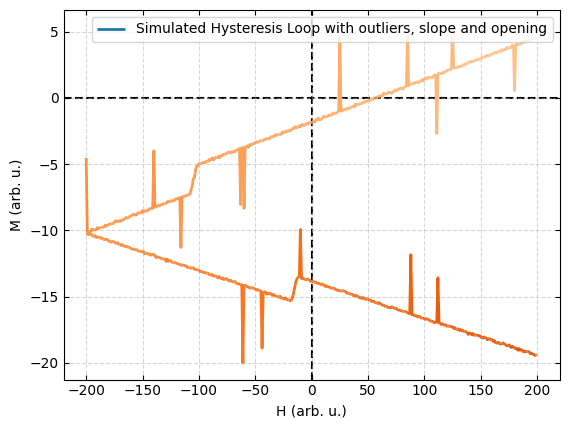

In [3]:
from pathlib import Path
from evaluix.utils import SupportFunctions as sf
import pandas as pd

csv_path = Path.cwd().parent / "_static" / "simulated" / "simulated_hysteresis_loop_with_all.csv"
data = pd.read_csv(csv_path)

print(data.head())

fields = data.iloc[:, 0].values
magnetization = data.iloc[:, 1].values

import matplotlib.pyplot as plt
import numpy as np
# import cmaps of matplotlib
import matplotlib.cm as cm
# plt.figure(figsize=(10, 6))
# plt.scatter(fields, magnetization, label='Original Data', edgecolor='k', s=30, zorder=5)
# plt.title('Simulated Hysteresis Loop with outliers, slope and opening')
# plt.xlabel('External magnetic Field [arb. u.]')
# plt.ylabel('Magnetization [arb. u.]')
# plt.tick_params(direction='in', top=True, right=True)
# plt.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
# plt.axvline(0, color='k', linestyle='--', label='H=0', zorder=1)
# plt.legend()
# plt.show()

# reduced colormaps for plotting (center 50%)
reduced_oranges_cmap = cm.get_cmap('Oranges', 256)
reduced_oranges_cmap = cm.colors.LinearSegmentedColormap.from_list(
    'reduced_oranges', 
    reduced_oranges_cmap(np.linspace(0.25, 0.75, 256))
)
reduced_blues_cmap = cm.get_cmap('Blues', 256)
reduced_blues_cmap = cm.colors.LinearSegmentedColormap.from_list(
    'reduced_blues', 
    reduced_blues_cmap(np.linspace(0.25, 0.75, 256))
)
reduced_greens_cmap = cm.get_cmap('Greens', 256)
reduced_greens_cmap = cm.colors.LinearSegmentedColormap.from_list(
    'reduced_greens', 
    reduced_greens_cmap(np.linspace(0.25, 0.75, 256))
)
reduced_purples_cmap = cm.get_cmap('Purples', 256)
reduced_purples_cmap = cm.colors.LinearSegmentedColormap.from_list(
    'reduced_purples', 
    reduced_purples_cmap(np.linspace(0.25, 0.75, 256))
)

sf.plot_loop(fields, 
             magnetization, 
             label='Simulated Hysteresis Loop with outliers, slope and opening',
            color=reduced_oranges_cmap,
            plotstyle='line',
            vmin=-0.1, vmax=1.1
)

If such a hysteresis is measured, the best practice would be to repeat the measurement in question. However, there are occurences where this is not possible or very time consuming, for example when the sample has been modified/destroyed or strong training effects are present. For such cases, the following procedure has been created to enable teh evaluation of such hysteresis curves. Nevertheless, modifications of data should always be performed with caution. 

__Note:__ At the end of this tutorial, there are a few notes about magnetic effects which may be modified or even compensated by these manipulation functions 

The order of manipulations is important! 
- Outliers affect the calculation of the trends for the other manipulations and should be removed first, although it is more difficult with other trends present.
- The opening is a trend in time/point number. Calculating the trend in time is (ideally) independent from trends in the field and should be compensated first. Otherwise, the trends in the fields are overlapped by them.
- Normalization assumes that the outermost part (typ. 5% but can be selected) is in saturation and normalizes everything to thes values. Therefore, the saturated part should be a horizontal line and all other effects should be compensated before.

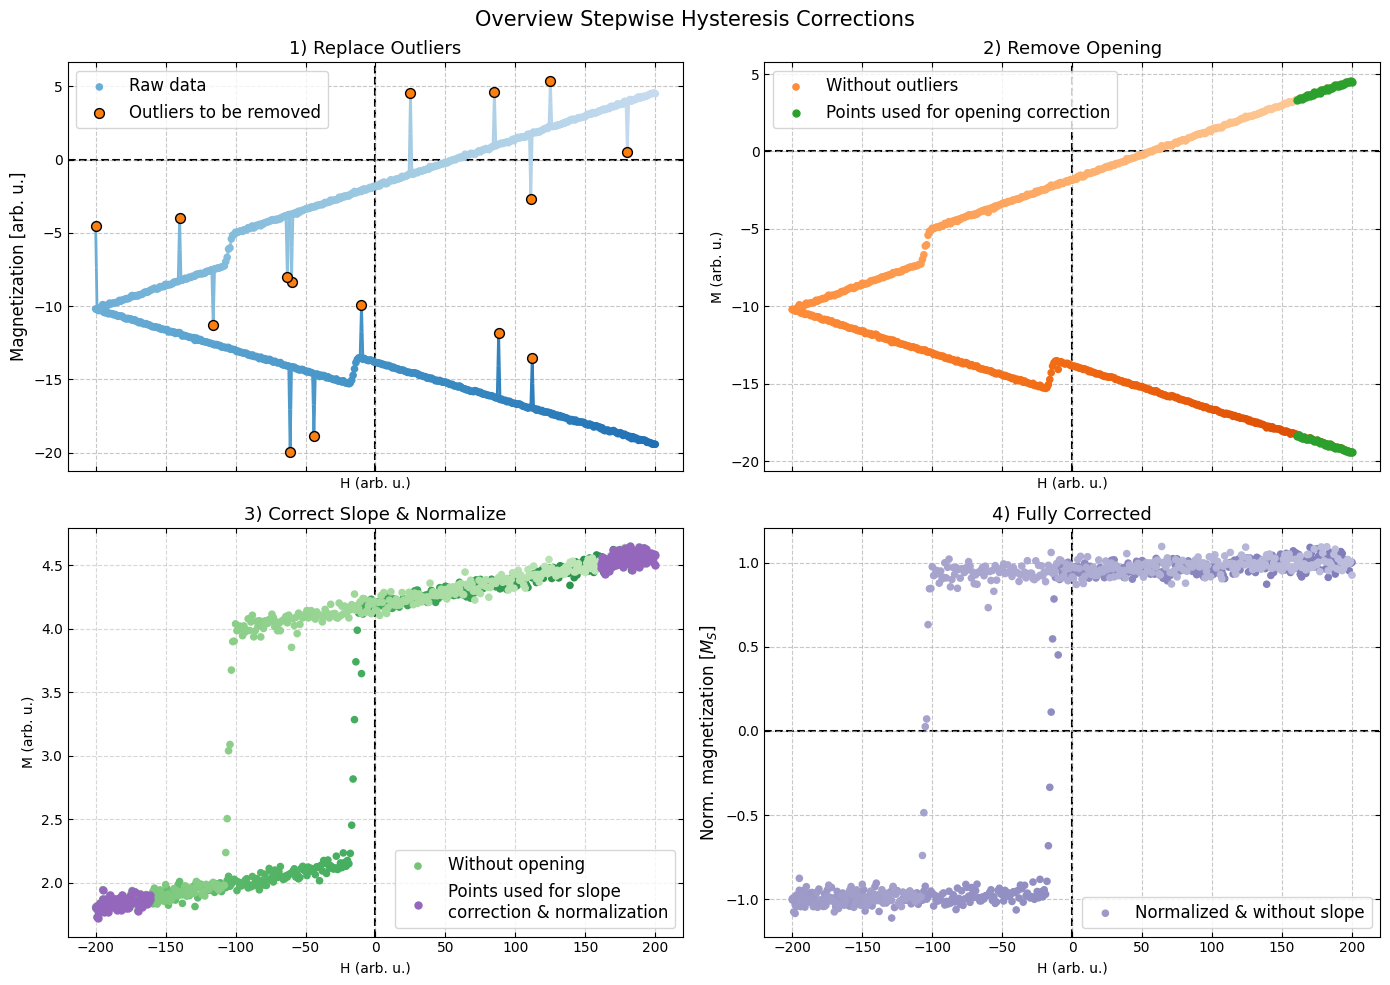

In [4]:
from evaluix.utils import HysteresisFunctions as hf
import numpy as np

# Keep original data unchanged
raw_data = magnetization.copy()

# 1. Remove outliers
without_outliers, outliers = hf.del_outliers(raw_data.copy(), return_details=True)

# 2. Remove opening at saturation
removed_opening, opening_details = hf.rmv_opening(without_outliers.copy(), return_details=True)

# 3. Remove slope at saturation
without_slope, slope_details = hf.slope_correction(fields, removed_opening.copy(), return_details=True)

# 4. Normalize magnetization
normalized_without_slope, norm_details = hf.hys_norm(fields, without_slope.copy(), return_details=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fontsize = 12

# Panel 1: Raw data
ax = axes[0, 0]
sf.plot_loop(fields, raw_data, label='Raw data', color=reduced_blues_cmap, plotstyle='both', ax=ax)
# ax.scatter(fields, raw_data, color='tab:blue', s=25, zorder=5, label='Raw data')
outlier_indices = outliers['indices_outliers']
if len(outlier_indices) > 0:
    ax.scatter(fields[outlier_indices], raw_data[outlier_indices], color='tab:orange', s=50, edgecolor='k', zorder=7, label='Outliers to be removed')
# ax.plot(fields, raw_data, color='tab:orange', linestyle='--', zorder=4)
ax.set_title('1) Replace Outliers', fontsize=fontsize + 1)
ax.set_ylabel('Magnetization [arb. u.]', fontsize=fontsize)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.legend(fontsize=fontsize, loc='best')

# Panel 2: Without outliers
ax = axes[0, 1]
sf.plot_loop(fields, without_outliers, label='Without outliers', color=reduced_oranges_cmap, plotstyle='scatter', ax=ax)
ax.scatter(fields[:opening_details['sat_points']], without_outliers[:opening_details['sat_points']], color='tab:green', s=25, zorder=6, label='Points used for opening correction')
ax.scatter(fields[-opening_details['sat_points']:], without_outliers[-opening_details['sat_points']:], color='tab:green', s=25, zorder=6)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.legend(fontsize=fontsize, loc='best')
ax.set_title('2) Remove Opening', fontsize=fontsize + 1)

# Panel 3: Removed opening
ax = axes[1, 0]
sf.plot_loop(fields, removed_opening, label='Without opening', color=reduced_greens_cmap, plotstyle='scatter', ax=ax)
#highlight the outermost 10% of the data points used for slope correction and normalization
# define sat_region in field strength
sat_field_range = 0.1 * (np.max(fields) - np.min(fields))
# take end regions of hysteresis (saturated regions) by calculating the field
# strengths which are assumed to be in saturation
upper_saturation_limit = np.max(fields) - sat_field_range
lower_saturation_limit = np.min(fields) + sat_field_range
# take end regions of hysteresis (saturated regions of both branches)
upper_saturation_region = fields > upper_saturation_limit
lower_saturation_region = fields < lower_saturation_limit
ax.scatter(fields[upper_saturation_region], removed_opening[upper_saturation_region], color='tab:purple', s=25, zorder=6, label='Points used for slope\ncorrection & normalization')
ax.scatter(fields[lower_saturation_region], removed_opening[lower_saturation_region], color='tab:purple', s=25, zorder=6)

ax.set_title('3) Correct Slope & Normalize', fontsize=fontsize + 1)
ax.legend(fontsize=fontsize, loc='best')

# Panel 4: Last two steps (slope correction + normalization) in one plot
ax = axes[1, 1]
sf.plot_loop(fields, normalized_without_slope, label='Normalized & without slope', color=reduced_purples_cmap, plotstyle='scatter', ax=ax, vmin=-0.5, vmax=1.5)
# ax.scatter(fields, normalized_without_slope, color='tab:purple', s=20, zorder=6, label='Normalized & without slope')
ax.set_title('4) Fully Corrected', fontsize=fontsize + 1)
ax.set_ylabel('Norm. magnetization [$M_S$]', fontsize=fontsize)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.legend(fontsize=fontsize, loc='best')

plt.suptitle('Overview Stepwise Hysteresis Corrections', fontsize=fontsize + 3)
plt.tight_layout()
plt.show()


### Delete Outliers

Outliers are individual points where something went wrong during the measurement. The most prominent case in our instruments is the LMOKE where sometimes, a timing mismatch between the detector and the Ni-Box can occur, leading to one or two single points per hysteresis with a way higher or lower intensity. As outliers will affect the data manipulation of the other manipulation steps as well as the analysis (covered in __HysteresisDataEvaluation__), it is recommended to get rid of them, either by remeasuring the curve (if reasonable) or by applying the ``del_outliers()`` function of Evaluix.

As the name implies, outliers drastically differ from their expected value. As the expected value is often unknown in experiments, it is approximated by the points in close vicinity. So, for each point in _ydata_, the function ``del_outliers(ydata, threshold, neighbours)`` compares the difference to the median of its _&plusmn;neighbours_ with the median of absolute differences (mad) of the same neighbours. If the difference exceeds the mad, weighted by the _threshold_, the point is considered an outlier. Thus, each point is compared to the local noise level (or data spread) in order to determine whether it is an outlier or not. If the point was identified as an outlier, it is replaced by the mean of the _&plusmn;neighbours_ as a simple interpolation. The median and median of absolute differences are used because they are very robust to outliers and thus not effected by the outliers which are to be replaced.

Note:
The higher the outlier threshold or the number of neighbours the less likely a point is fullfilling the outlier condition, marking it as an outlier. I.e. higher thresholds or number of neighbours make it more likely that only true outliers are recognized as long as they are still recognized at all. For the plot above, this means, that the points marked in yellow are also recognized by ALL the parameter combinations with a lower threshold or less considered neighbours.
Special Note: In early versions of Evaluix, the default value for the threshold and the number of outliers was set to ``thresh=2`` and ``neighbours=5``, which is only on the lower limit of the plots above. With such parameters the function resembles a conditional noise reduction by a rolling average, only acting on the outer points of the noise. It is recommended to upgrade Evaluix or increase the conditions by hand.

   Applied Field (H [arb. u.])  Magnetization with slope
0                        200.0                  4.102451
1                        199.0                  4.186659
2                        198.0                  4.175292
3                        197.0                  4.200445
4                        196.0                  4.191541


/tmp/ipykernel_1511/2707766952.py:30: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(fields[idx_both], magnetization[idx_both], s=120, c=color_list[i], marker="X", edgecolor="k",
/tmp/ipykernel_1511/2707766952.py:48: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(fields[idx_both], magnetization[idx_both], s=120, c=color_list[i], marker="X", edgecolor="k",


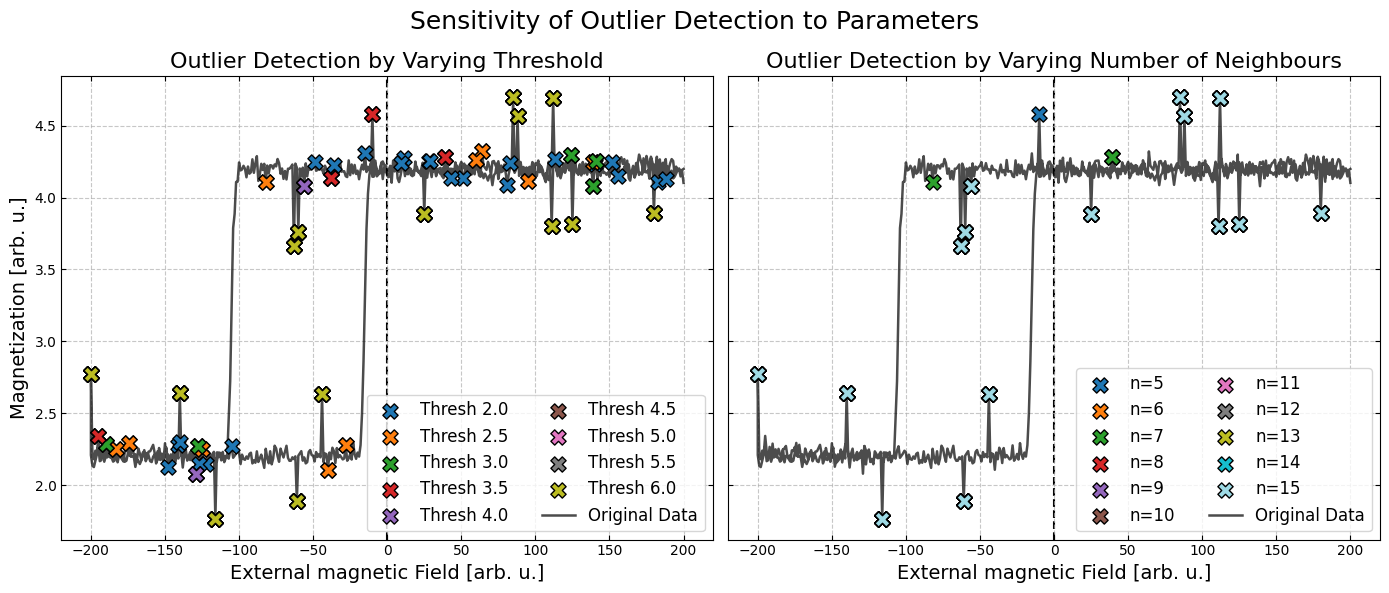

In [5]:
csv_path = Path.cwd().parent / "_static" / "simulated" / "simulated_hysteresis_loop_with_outliers.csv"
data = pd.read_csv(csv_path)

print(data.head())

fields = data.iloc[:, 0].values
magnetization = data.iloc[:, 1].values

# Plot with 2 figures, the left shows the dependence on the threshold for a fixed number of neighbours of 10, the right shows the dependence on the number of neighbours for a fixed threshold of 5
cleaned_data_thresh = {}
details_thresh = {}
for thresh in np.arange(2, 6.1, 0.5):
    cleaned, details_thresh[thresh] = hf.del_outliers(magnetization.copy(), return_details=True, threshold=thresh, neighbours=10)
    cleaned_data_thresh[thresh] = cleaned
cleaned_data_neigh = {}
details_neigh = {}
for neigh in range(5, 16):
    cleaned, details_neigh[neigh] = hf.del_outliers(magnetization.copy(), return_details=True, threshold=5, neighbours=neigh)
    cleaned_data_neigh[neigh] = cleaned
    
# color list to show at which threshold/neighbour number the outliers were detected
color_list = plt.cm.tab20(np.linspace(0, 1, max(len(cleaned_data_thresh), len(cleaned_data_neigh))))
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
# Left panel: varying threshold
ax = axes[0]
for i, (thresh, cleaned) in enumerate(cleaned_data_thresh.items()):
    details = details_thresh[thresh]
    idx_both = details["indices_outliers"]
    if len(idx_both):
        ax.scatter(fields[idx_both], magnetization[idx_both], s=120, c=color_list[i], marker="X", edgecolor="k",
                   label=f"Thresh {thresh:.1f}", zorder=4)
    
fontsize = 14
ax.plot(fields, magnetization, c='k', lw=1.8, label=f"Original Data", zorder=2, alpha=0.7)
ax.set_title("Outlier Detection by Varying Threshold", fontsize=fontsize + 2)
ax.set_xlabel("External magnetic Field [arb. u.]", fontsize=fontsize)
ax.set_ylabel("Magnetization [arb. u.]", fontsize=fontsize)
ax.grid(which="both", linestyle="--", alpha=0.7, zorder=0)
ax.axvline(0, color="k", linestyle="--", zorder=0)
ax.tick_params(direction="in", top=True, right=True)
ax.legend(fontsize=fontsize - 2, loc="best", ncol=2)
# Right panel: varying number of neighbours
ax = axes[1]
for i, (neigh, cleaned) in enumerate(cleaned_data_neigh.items()):
    details = details_neigh[neigh]
    idx_both = details["indices_outliers"]
    if len(idx_both):
        ax.scatter(fields[idx_both], magnetization[idx_both], s=120, c=color_list[i], marker="X", edgecolor="k",
                   label=f"n={neigh}", zorder=4)

ax.plot(fields, magnetization, c='k', lw=1.8, label=f"Original Data", zorder=2, alpha=0.7)
ax.set_title("Outlier Detection by Varying Number of Neighbours", fontsize=fontsize + 2)
ax.set_xlabel("External magnetic Field [arb. u.]", fontsize=fontsize)
ax.grid(which="both", linestyle="--", alpha=0.7, zorder=0)
ax.axvline(0, color="k", linestyle="--", zorder=0)
ax.tick_params(direction="in", top=True, right=True)
ax.legend(fontsize=fontsize - 2, loc="best", ncol=2)
plt.suptitle("Sensitivity of Outlier Detection to Parameters", fontsize=fontsize + 4)
plt.tight_layout()
plt.show()

### Remove Opening

A hysteresis opening is caused by a changing signal over time, which is not associated with external magnetic fields or magnetization reversal phenomena within the sample. Examples for such effects are unstable light sources in MOKE setups, sample drifts in Kerr microscopy (showing a different region with a different magnetization and/or reflectivity) or a shift of the sample in the VSM when the setup is warming up or the sample is loose.

As the effect is not associated by the magnetic properties of the sample, this effect causes a signal difference between the initial magnetic state at the start of a measurement and the final magnetic state at its end, i.e. a hysteresis opening (assuming a major hysteresis loop, where initial and final magnetic state represent the identical saturated magnetic state).
As the signal contains non-magnetic contributions in addition to the magnetic hysteresis loop, it is recommended to remeasure it without the parasitic effect (if reasonable) or trying to compensate it with the ``rmv_opening()`` function of Evaluix.


   Applied Field (H [arb. u.])  Magnetization with slope
0                        200.0                  4.102451
1                        199.0                  4.156659
2                        198.0                  4.115292
3                        197.0                  4.110445
4                        196.0                  4.071541


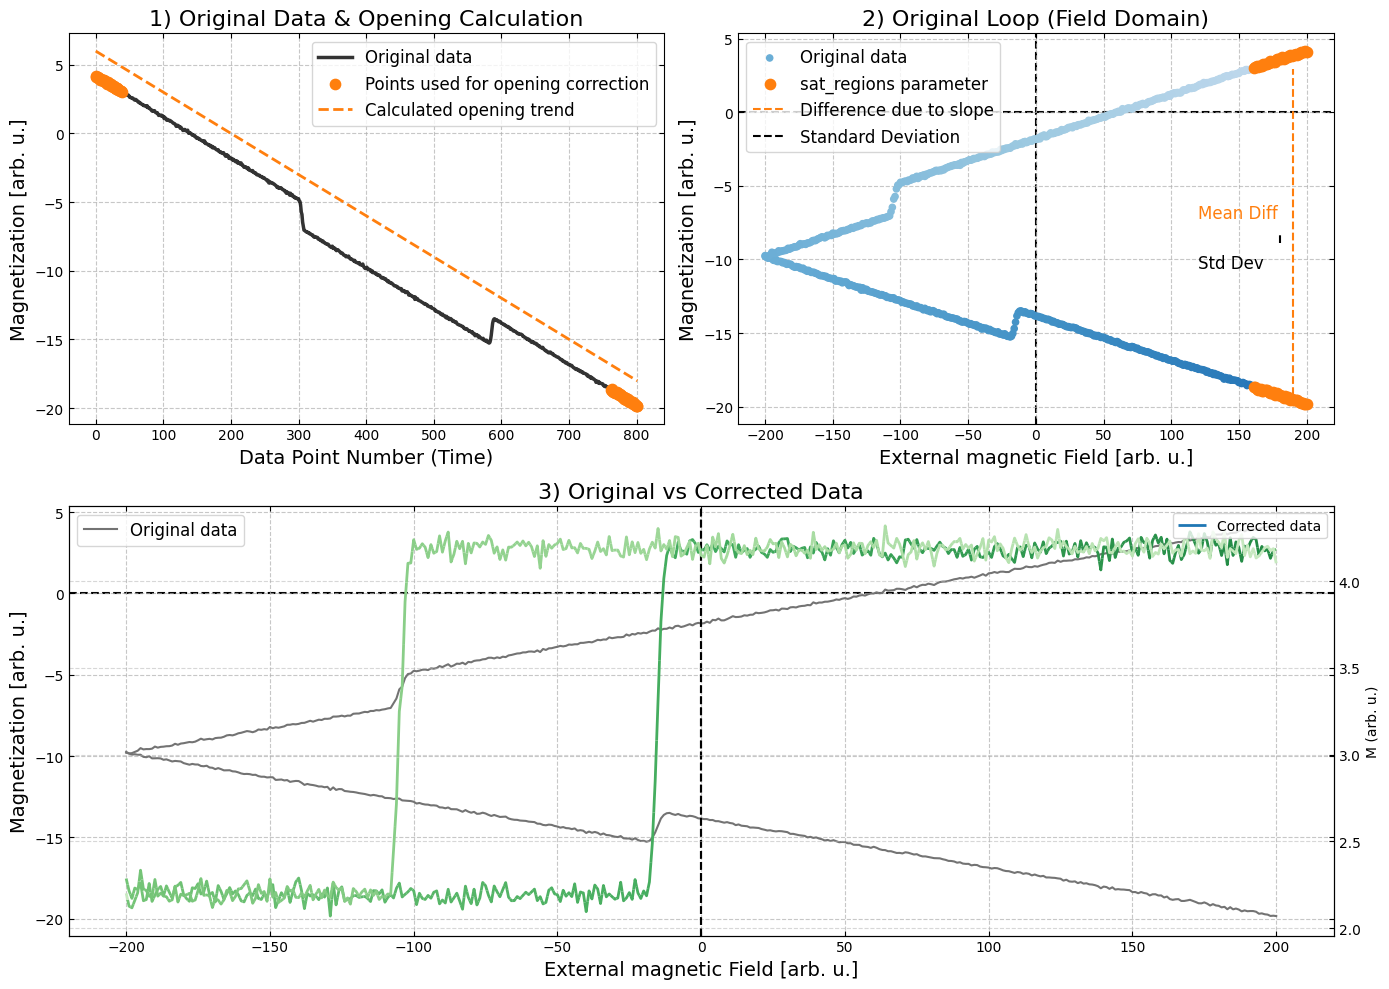

In [ ]:
csv_path = Path.cwd().parent / "_static" / "simulated" / "simulated_hysteresis_loop_with_opening.csv"
data = pd.read_csv(csv_path)

print(data.head())

fields = data.iloc[:, 0].values
magnetization = data.iloc[:, 1].values

corr_magnetization, details = hf.rmv_opening(magnetization.copy(), return_details=True)

# Three-panel layout:
# top-left: opening trend over point number
# top-right: original loop with points used for opening correction
# bottom (full width): original vs corrected loop
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1.1], width_ratios=[1, 1])
fontsize = 14

# Left panel: magnetization vs point number (time)
ax = fig.add_subplot(gs[0, 0])
points = np.arange(len(magnetization))
sat_points_mask = np.zeros_like(points, dtype=bool)
sat_points_mask[:details['sat_points']] = True
sat_points_mask[-details['sat_points']:] = True

ax.plot(points, magnetization, c='k', lw=2.5, label='Original data', zorder=2, alpha=0.8)
ax.scatter(
    points[sat_points_mask],
    magnetization[sat_points_mask],
    color='tab:orange',
    s=55,
    label='Points used for opening correction',
    zorder=4,
)

opening_slope = details['opening_slope']
# Anchor display line at first selected saturation point for readability
anchor_idx = np.where(sat_points_mask)[0][0] if np.any(sat_points_mask) else 0
anchor_y = 6
opening_line = opening_slope * (points - anchor_idx) + anchor_y
ax.plot(
    points,
    opening_line,
    color='tab:orange',
    linestyle='--',
    linewidth=2,
    label='Calculated opening trend',
    zorder=3,
)

ax.set_title('1) Original Data & Opening Calculation', fontsize=fontsize + 2)
ax.set_xlabel('Data Point Number (Time)', fontsize=fontsize)
ax.set_ylabel('Magnetization [arb. u.]', fontsize=fontsize)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.tick_params(direction='in', top=True, right=True)
ax.legend(fontsize=fontsize - 2, loc='best')

# Right panel: original loop and highlighted opening-correction points
ax = fig.add_subplot(gs[0, 1])
sf.plot_loop(fields, magnetization, label='Original data', color=reduced_blues_cmap, plotstyle='scatter', ax=ax)
ax.scatter(
    fields[sat_points_mask],
    magnetization[sat_points_mask],
    color='tab:orange',
    s=55,
    label='sat_regions parameter',
    zorder=4,
)
# plot the criterium for opening correction as vertical lines, which is the sum of the std of both branches vs the difference of the mean of both branches#
mean_diff = details['mean_diff']
hys_mean = np.mean(magnetization)
std_dev = details['standard_deviation']

ax.plot([0.95*max(fields), 0.95*max(fields)], [-0.5*mean_diff+hys_mean, 0.5*mean_diff+hys_mean], color='tab:orange', linestyle='--', zorder=3, label="Difference due to slope")
ax.text(0.6*max(fields), 0.8*hys_mean, 'Mean Diff', color='tab:orange', fontsize=fontsize - 2, va='center', ha='left')

ax.plot([0.9*max(fields), 0.9*max(fields)], [-0.5*std_dev+hys_mean, 0.5*std_dev+hys_mean], color='k', linestyle='--', zorder=3, label="Standard Deviation")
ax.text(0.6*max(fields), 1.2*hys_mean, 'Std Dev', color='k', fontsize=fontsize - 2, va='center', ha='left')

ax.set_title('2) Original Loop (Field Domain)', fontsize=fontsize + 2)
ax.set_xlabel('External magnetic Field [arb. u.]', fontsize=fontsize)
ax.set_ylabel('Magnetization [arb. u.]', fontsize=fontsize)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.tick_params(direction='in', top=True, right=True)
ax.legend(fontsize=fontsize - 2, loc='upper left')

# Bottom panel spanning full width: original vs corrected
ax = fig.add_subplot(gs[1, :])
sf.plot_loop(fields, magnetization, label='Original data', color='0.45', plotstyle='line', ax=ax)
# twin y-axis to show opening trend
ax2 = ax.twinx()
sf.plot_loop(fields, corr_magnetization, label='Corrected data', color=reduced_greens_cmap, plotstyle='line', ax=ax2)

ax.set_title('3) Original vs Corrected Data', fontsize=fontsize + 2)
ax.set_xlabel('External magnetic Field [arb. u.]', fontsize=fontsize)
ax.set_ylabel('Magnetization [arb. u.]', fontsize=fontsize)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.tick_params(direction='in', top=True, right=True)
ax.legend(fontsize=fontsize - 2, loc='best')

plt.tight_layout()
plt.show()

   Applied Field (H [arb. u.])  Magnetization with slope
0                        200.0                  4.502451
1                        199.0                  4.584659
2                        198.0                  4.571292
3                        197.0                  4.594445
4                        196.0                  4.583541


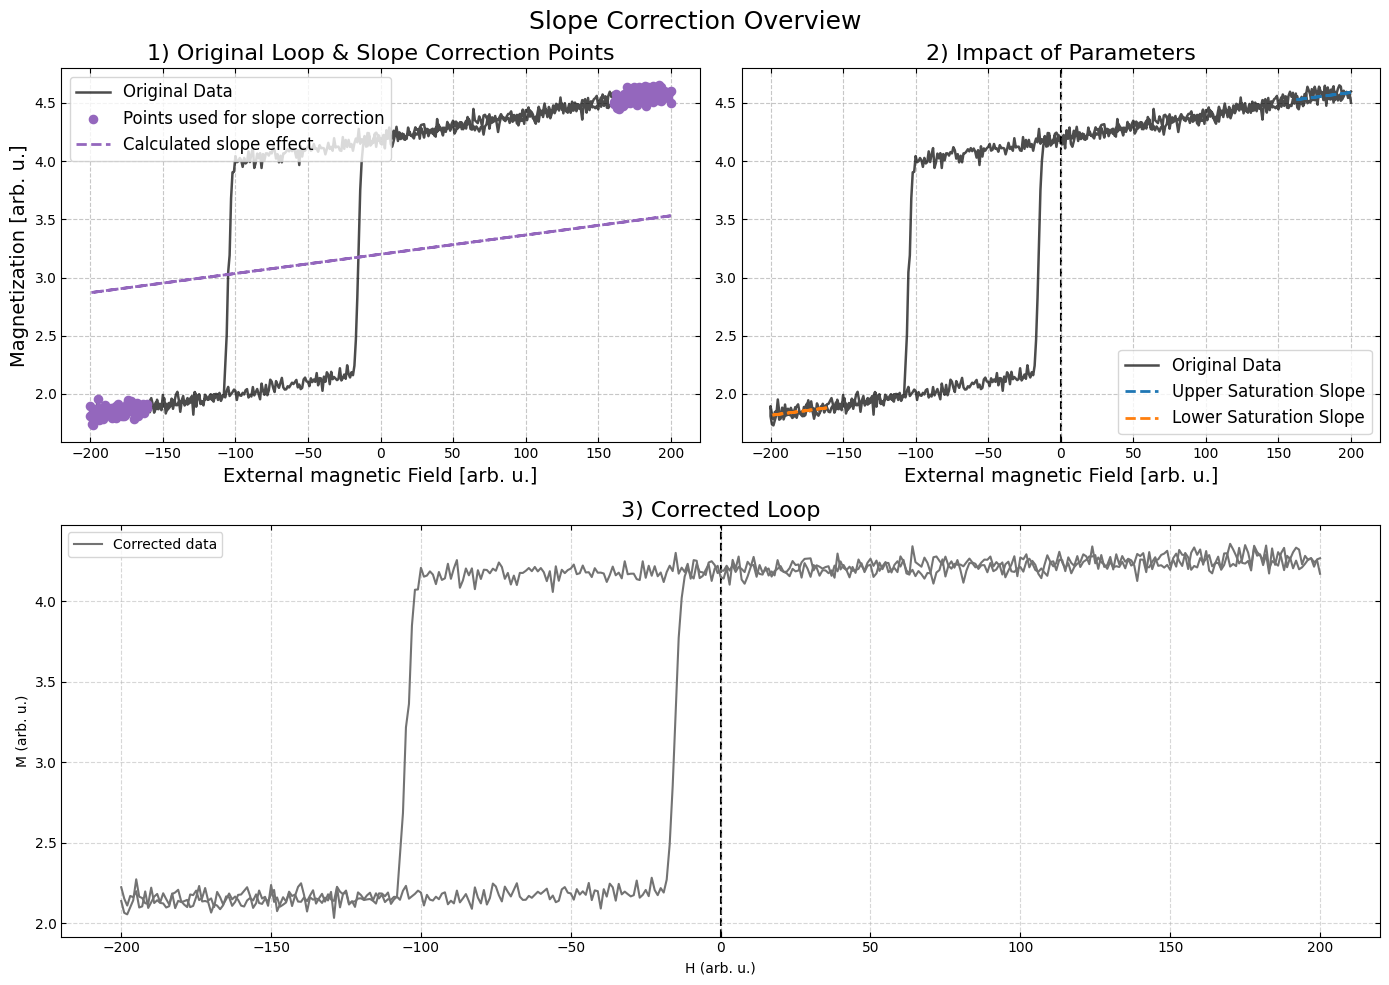

In [39]:
# Slope correction example
csv_path = Path.cwd().parent / "_static" / "simulated" / "simulated_hysteresis_loop_with_slope.csv"
data = pd.read_csv(csv_path)

print(data.head())

fields = data.iloc[:, 0].values
magnetization = data.iloc[:, 1].values

corr_magnetization, details = hf.slope_correction(fields, magnetization.copy(), return_details=True)
slope = details['slope']
noise_level = details['noise_level']
slope_effect = details['slope_effect']
norm_slope_diff = details['norm_slope_diff']

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1.1], width_ratios=[1, 1])
fontsize = 14
# Left panel: original loop with points used for slope correction
ax = fig.add_subplot(gs[0, 0])
ax.plot(fields, magnetization, c='k', lw=1.8, label=f"Original Data", zorder=2, alpha=0.7)
# highlight the outermost 10% of the data points used for slope correction
sat_field_range = 0.1 * (np.max(fields) - np.min(fields))
upper_saturation_limit = np.max(fields) - sat_field_range
lower_saturation_limit = np.min(fields) + sat_field_range
upper_saturation_region = fields > upper_saturation_limit
lower_saturation_region = fields < lower_saturation_limit
ax.scatter(fields[upper_saturation_region], magnetization[upper_saturation_region], color='tab:purple', s=35, zorder=4, label='Points used for slope correction')
ax.scatter(fields[lower_saturation_region], magnetization[lower_saturation_region], color='tab:purple', s=35, zorder=4)

# Plot a line representing the slope effect calculated from the selected points
slope_line = slope * fields + 3.2
ax.plot(fields, slope_line, color='tab:purple', linestyle='--', linewidth=2, label='Calculated slope effect')

ax.set_title('1) Original Loop & Slope Correction Points', fontsize=fontsize + 2)
ax.set_xlabel('External magnetic Field [arb. u.]', fontsize=fontsize)
ax.set_ylabel('Magnetization [arb. u.]', fontsize=fontsize)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.tick_params(direction='in', top=True, right=True)
ax.legend(fontsize=fontsize - 2, loc='upper left')

ax = fig.add_subplot(gs[0, 1])

ax.plot(fields, magnetization, c='k', lw=1.8, label=f"Original Data", zorder=2, alpha=0.7)
popt1, pcov1 = hf.curve_fit(hf.linear, fields[upper_saturation_region], magnetization[upper_saturation_region])
popt2, pcov2 = hf.curve_fit(hf.linear, fields[lower_saturation_region], magnetization[lower_saturation_region])
# plot the individual slopes for upper and lower saturation regions
ax.plot(fields[upper_saturation_region], hf.linear(fields[upper_saturation_region], *popt1), color='tab:blue', linestyle='--', linewidth=2, label='Upper Saturation Slope')
ax.plot(fields[lower_saturation_region], hf.linear(fields[lower_saturation_region], *popt2), color='tab:orange', linestyle='--', linewidth=2, label='Lower Saturation Slope')



ax.set_title('2) Impact of Parameters', fontsize=fontsize + 2)
ax.set_xlabel('External magnetic Field [arb. u.]', fontsize=fontsize)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.axvline(0, color='k', linestyle='--', zorder=0)
ax.tick_params(direction='in', top=True, right=True)
ax.legend(fontsize=fontsize - 2, loc='best')

ax = fig.add_subplot(gs[1, :])
sf.plot_loop(fields, corr_magnetization, label='Corrected data', color='0.45', plotstyle='line', ax=ax)
ax.set_title('3) Corrected Loop', fontsize=fontsize + 2)

plt.suptitle('Slope Correction Overview', fontsize=fontsize + 4)
plt.tight_layout()
plt.show()